In [1]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
from tqdm.auto import tqdm
tqdm.pandas()
import os
import math
df_moves = pd.read_csv('0211.csv')

In [2]:
tolerance_cp= 10
df_moves['Is_Optimal'] = np.where(df_moves['Δi'] <= tolerance_cp, 1, 0)
#df_moves.head(50)
df_moves['Game_Length'] = (
    df_moves.groupby('uid')['Move_Idx'].transform('max')
)

df_moves['Progress'] = (
    df_moves['Move_Idx'] / df_moves['Game_Length']
)
def get_relative_stage(progress):
    if progress <= 0.33:
        return 'Opening (0-33%)'
    elif progress <= 0.66:
        return 'Middlegame (33-66%)'
    else:
        return 'Endgame (66-100%)'
df_moves['Relative_Stage(temp)'] = df_moves['Progress'].apply(get_relative_stage)

In [3]:
df_moves['Δ'].describe

<bound method NDFrame.describe of 0            7.0
1            4.0
2            8.0
3           39.0
4           16.0
           ...  
9086329     85.0
9086330     10.0
9086331     15.0
9086332     10.0
9086333    263.0
Name: Δ, Length: 9086334, dtype: float64>

# 老旧数据跑出来的结果
| ELO Group     | A (Performance Ceiling) | 0.73·A | Inferred τ (cp) |
|--------------|--------------------------|--------|-------------------|
| ≥ 3000       | 0.772                    | 0.563  | **105.3**         |
| 2800–3000    | 0.749                    | 0.547  | **113.3**         |
| 2600–2800    | 0.733                    | 0.535  | **118.5**         |
| 2400–2600    | 0.712                    | 0.519  | **122.5**         |
| 2200–2400    | 0.691                    | 0.505  | **138.3**         |
| 2000–2200    | 0.679                    | 0.496  | **129.8**         |
| < 2000       | 0.656                    | 0.479  | **Not estimable at this stage** |

# 较大数据集跑出的结果    

| ELO Group   | A (Performance Ceiling) | 0.73·A | Inferred τ (cp) |
|-------------|-------------------------|--------|------------------|
| ≥ 3000      | 0.786                   | 0.573  | **65.8**         |
| 2800–3000   | 0.766                   | 0.559  | **85.4**         |
| 2600–2800   | 0.742                   | 0.542  | **113.2**        |
| 2400–2600   | 0.720                   | 0.525  | **129.0**        |
| 2200–2400   | 0.697                   | 0.509  | **144.7**        |
| 2000–2200   | 0.669                   | 0.488  | **185.6**        |
| < 2000      | 0.645                   | 0.471  | **170.8**        |

In [4]:
pd.set_option('display.max_columns', None)
df_moves.head()

,Unnamed: 0,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time,Game_Length,Progress,Relative_Stage(temp)
0,0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170),1.3,63,0.015873,Opening (0-33%)
1,1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,3.0,4.0,2463,2400-2600,0,1,177.8,Rich (>170),-0.9,63,0.031746,Opening (0-33%)
2,2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,6.0,8.0,2802,2800-3000,0,1,178.5,Rich (>170),-0.7,63,0.047619,Opening (0-33%)
3,3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170),0.4,63,0.063492,Opening (0-33%)
4,4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170),0.1,63,0.079365,Opening (0-33%)


In [5]:
# 1. 准备工作：定义分组阈值字典
τ_map = {
    '>=3000': 65.8,
    '2800-3000': 85.4,
    '2600-2800': 113.2,
    '2400-2600': 129.0,
    '2200-2400': 144.7,
    '2000-2200': 185.6,
    '<2000': 170.8,     # 手动补全
    'Unknown': 120.0    # 默认值
}

# 2. 关键步骤：利用 map 生成一列对齐的 Delta0
# 这行代码会瞬间给几百万行数据填上对应的 Delta0
df_moves['τ_Group'] = df_moves['ELO_Group'].map(τ_map)

# 处理一下 map 之后可能产生的 NaN (如果有漏掉的组)，填充为默认值 100
df_moves['τ_Group'] = df_moves['τ_Group'].fillna(100.0)

print("τ_Group 列生成完毕 预览：")
print(df_moves[['ELO_Group', 'τ_Group']].head())

# --- 开始向量化计算 ---

# 1. 计算 P (Group specific)
# 公式： 1 / (1 + exp(-Δ / Δ0_group))
delta_values = df_moves['Δ'].values
τ_values = df_moves['τ_Group'].values  # 取出这一列作为分母数组

# 同样使用 numpy 向量运算
p_values_group = 1 / (1 + np.exp(-delta_values / τ_values))

# 赋值 (不带 Global 后缀)
df_moves['P_model'] = p_values_group

# 2. 计算 S (Group specific)
# 同样处理 P接近0 的情况
df_moves['S'] = np.where(
    p_values_group > 1e-9, 
    -np.log2(p_values_group), 
    1.0
)

# 3. 计算 S/t (Group specific)
# 处理时间为 0 的情况
# safe_time = complex_drop_opening['Move_Time'].replace(0, 0.1) 
# complex_drop_opening['Cognitive_Speed'] = complex_drop_opening['S'] / safe_time

τ_Group 列生成完毕 预览：
   ELO_Group  τ_Group
0  2800-3000     85.4
1  2400-2600    129.0
2  2800-3000     85.4
3  2400-2600    129.0
4  2800-3000     85.4


In [6]:
pd.set_option('display.max_columns', None)
df_moves.head()

,Unnamed: 0,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time,Game_Length,Progress,Relative_Stage(temp),τ_Group,P_model,S
0,0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170),1.3,63,0.015873,Opening (0-33%),85.4,0.520480,0.942084
1,1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,3.0,4.0,2463,2400-2600,0,1,177.8,Rich (>170),-0.9,63,0.031746,Opening (0-33%),129.0,0.507751,0.977806
2,2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,6.0,8.0,2802,2800-3000,0,1,178.5,Rich (>170),-0.7,63,0.047619,Opening (0-33%),85.4,0.523402,0.934008
3,3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170),0.4,63,0.063492,Opening (0-33%),129.0,0.575011,0.798339
4,4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170),0.1,63,0.079365,Opening (0-33%),85.4,0.546702,0.871174


$$
\text{Cognitive\_Speed}_{\text{each move}} = \frac{Δ_{\text{each move}}}{t_{\text{each move}}}
$$    
                                                             only calculate from 'Is_Optimal == 1' moves

## p_model part1: global & coginitive speed calculation

In [7]:
GLOBAL_τ_List = [10.0, 50.0, 100.0, 150.0]  #论文的值10cp画出来的图分布太不平衡了，改成我自己求出来的中间的数字

# 1. 计算 P和S (向量化)
# 使用 np.exp 可以直接处理整个数组
# 这里的 clip 是为了防止溢出
delta_values = df_moves['Δ'].values

for τ_group in GLOBAL_τ_List:
    # P
    p_values = 1 / (1 + np.exp(-delta_values / τ_group))
    p_col_name = f'P_model(Global={τ_group}cp)'
    df_moves[p_col_name] = p_values

    # S 可以考虑码掉不要S
    s_col_name = f'S(Global={τ_group}cp)'
    
    df_moves[s_col_name] = np.where(
        p_values > 1e-9,
        -np.log2(p_values),
        1.0
    )
print("新增列：")
print([col for col in df_moves.columns if "Global=" in col])

# 3. 计算 Δ/t (向量化)
time_complex = df_moves.loc[df_moves['Move_Time'].notna() &(df_moves['Move_Time'] >= 0) &(df_moves['Is_Optimal'] == 1)].reset_index(drop=True)
# 处理时间为 0 的情况
safe_permove_time = time_complex['Move_Time'].replace(0, 0.1) # 把0秒替换成0.1秒
time_complex['Cognitive_Speed'] = time_complex['Δ'] / safe_permove_time

print("计算完成！")
print(time_complex.shape)
print(df_moves.shape)
time_complex.head()

新增列：
['P_model(Global=10.0cp)', 'S(Global=10.0cp)', 'P_model(Global=50.0cp)', 'S(Global=50.0cp)', 'P_model(Global=100.0cp)', 'S(Global=100.0cp)', 'P_model(Global=150.0cp)', 'S(Global=150.0cp)']
计算完成！
(3589298, 38)
(9086334, 37)


,Unnamed: 0,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time,Game_Length,Progress,Relative_Stage(temp),τ_Group,P_model,S,P_model(Global=10.0cp),S(Global=10.0cp),P_model(Global=50.0cp),S(Global=50.0cp),P_model(Global=100.0cp),S(Global=100.0cp),P_model(Global=150.0cp),S(Global=150.0cp),Cognitive_Speed
0,0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170),1.3,63,0.015873,Opening (0-33%),85.4,0.520480,0.942084,0.668188,0.581675,0.534943,0.902543,0.517493,0.950389,0.511665,0.966730,5.384615
1,5,34,6,Petar Ratkovic,Black,39,32,37,67,71,72,-,0,0,7.0,24.0,2463,2400-2600,0,1,178.3,Rich (>170),0.0,63,0.095238,Opening (0-33%),129.0,0.546378,0.872029,0.916827,0.125278,0.617748,0.694910,0.559714,0.837239,0.539915,0.889196,240.000000
2,8,34,9,Dennis Wagner,White,32,39,23,17,12,11,-,0,0,7.0,21.0,2802,2800-3000,0,1,179.6,Rich (>170),0.2,63,0.142857,Opening (0-33%),85.4,0.561167,0.833497,0.890903,0.166659,0.603483,0.728614,0.552308,0.856455,0.534943,0.902543,105.000000
3,10,34,11,Dennis Wagner,White,42,50,40,29,26,18,-,0,0,8.0,18.0,2802,2800-3000,0,1,179.4,Rich (>170),0.9,63,0.174603,Opening (0-33%),85.4,0.552499,0.855956,0.858149,0.220700,0.589040,0.763561,0.544879,0.875992,0.529964,0.916034,20.000000
4,12,34,13,Dennis Wagner,White,56,66,58,48,35,28,-,0,0,10.0,19.0,2802,2800-3000,0,1,178.5,Rich (>170),2.8,63,0.206349,Opening (0-33%),85.4,0.555392,0.848421,0.869892,0.201093,0.593873,0.751773,0.547358,0.869444,0.531624,0.911521,6.785714


In [8]:
# 要改
complex_drop_force = df_moves.loc[(df_moves['Move_Time'].notna()) & (df_moves['Move_Time'] >= 0) & (df_moves['Is_Forced']==0)].reset_index(drop=True)

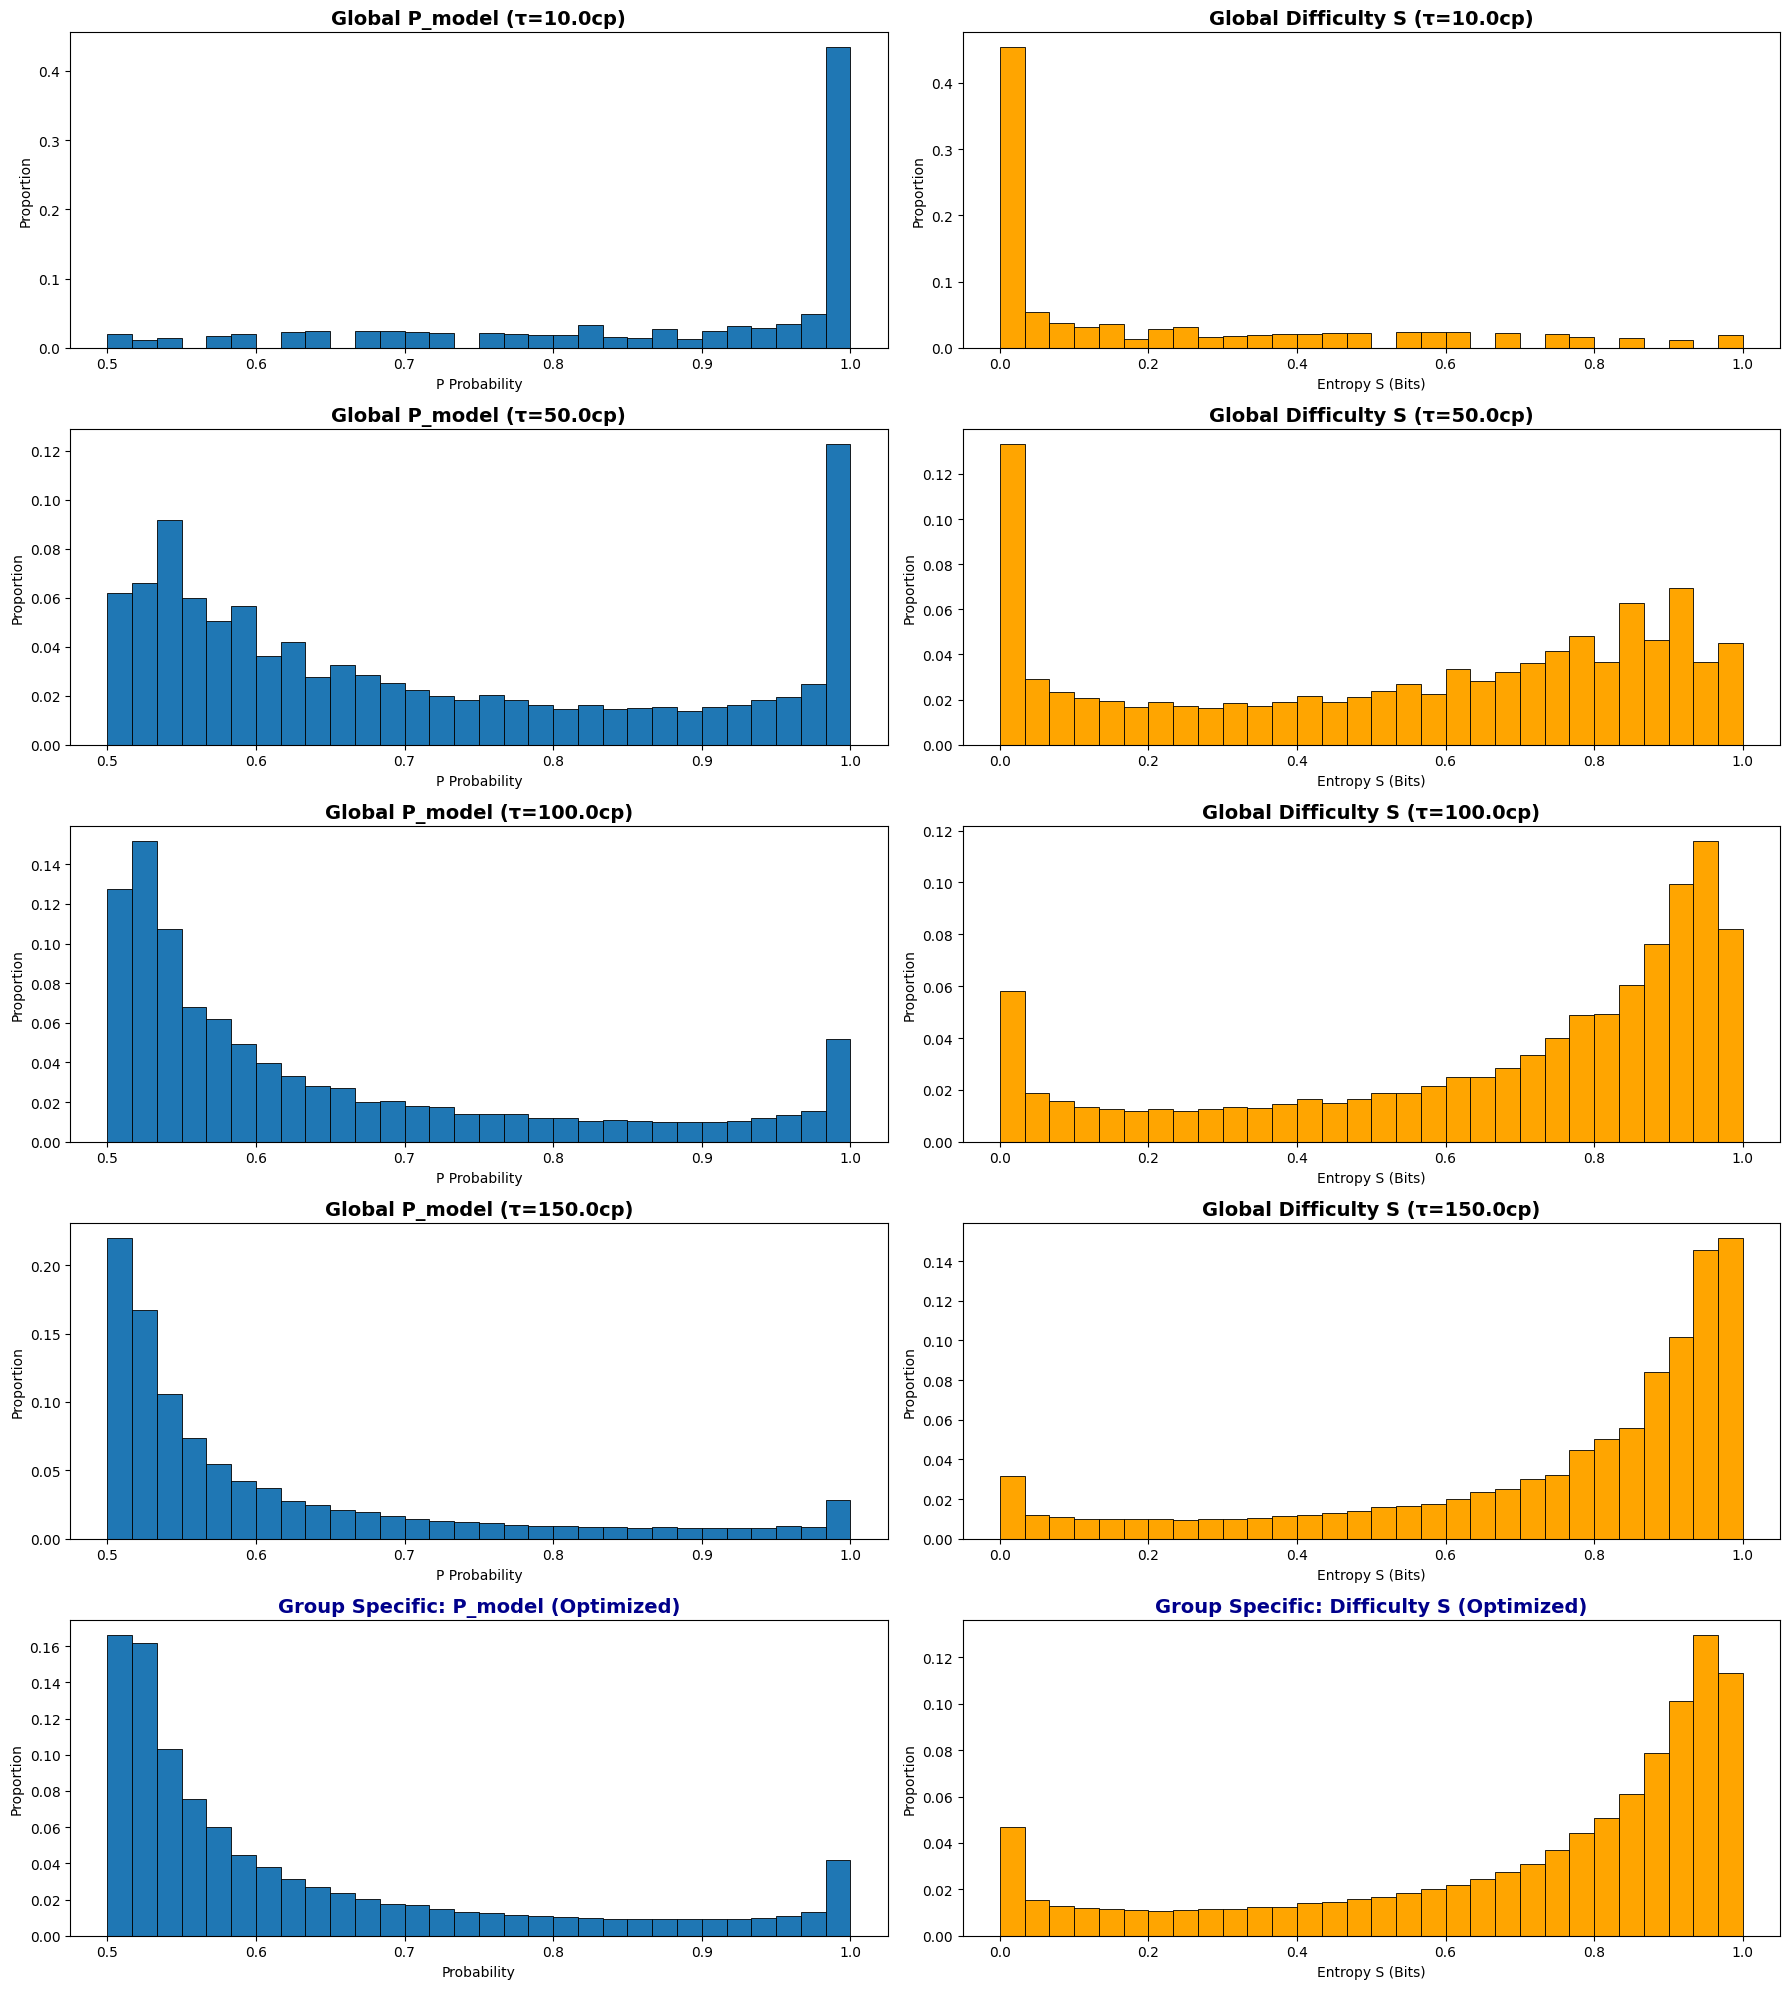

In [9]:
# 计算总行数
n_rows = len(GLOBAL_τ_List) + 1
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
# 列名匹配函数
def get_column_name(df, base_name, τ):
    col_float = f'{base_name}(Global={τ}cp)'
    col_int = f'{base_name}(Global={int(τ)}cp)'
    return col_float if col_float in df.columns else col_int


def fast_hist(ax, data, bins=30, color=None):
    counts, edges = np.histogram(data, bins=bins)
    prob = counts / counts.sum()
    width = np.diff(edges)
    ax.bar(edges[:-1], prob, width=width, align="edge", color=color, edgecolor="black", linewidth=0.6)

# Global τ
for i, τ in enumerate(GLOBAL_τ_List):

    p_col = get_column_name(complex_drop_force, 'P_model', τ)
    s_col = get_column_name(complex_drop_force, 'S', τ)

    if s_col not in complex_drop_force.columns:
        print(f"跳过: 找不到列 {s_col}")
        continue

    # P
    if p_col in complex_drop_force.columns:
        data = complex_drop_force[p_col].to_numpy()
        fast_hist(axes[i,0], data)
        axes[i,0].set_title(
            f'Global P_model (τ={τ}cp)',
            fontsize=14,
            fontweight='bold'
        )
        axes[i,0].set_xlabel('P Probability')
        axes[i,0].set_ylabel('Proportion')
    # S
    if s_col in complex_drop_force.columns:
        data = complex_drop_force[s_col].to_numpy()
        fast_hist(axes[i,1], data, color='orange')
        axes[i,1].set_title(
            f'Global Difficulty S (τ={τ}cp)',
            fontsize=14,
            fontweight='bold'
        )
        axes[i,1].set_xlabel('Entropy S (Bits)')
        axes[i,1].set_ylabel('Proportion')
# Group Specific
last_row_idx = n_rows - 1
if 'P_model' in complex_drop_force.columns:
    data = complex_drop_force['P_model'].to_numpy()
    fast_hist(axes[last_row_idx,0], data)
    axes[last_row_idx,0].set_title(
        'Group Specific: P_model (Optimized)',fontsize=14,fontweight='bold',color='darkblue')
    axes[last_row_idx,0].set_xlabel('Probability')
    axes[last_row_idx,0].set_ylabel('Proportion')

    data = complex_drop_force['S'].to_numpy() 
    fast_hist(axes[last_row_idx,1], data, color='orange')
    axes[last_row_idx,1].set_title('Group Specific: Difficulty S (Optimized)',fontsize=14,fontweight='bold',color='darkblue')
    axes[last_row_idx,1].set_xlabel('Entropy S (Bits)')
    axes[last_row_idx,1].set_ylabel('Proportion')


plt.tight_layout()
plt.show()

In [30]:
time_complex.head()

,Unnamed: 0,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time,Game_Length,Progress,Relative_Stage(temp),τ_Group,P_model,S,P_model(Global=10.0cp),S(Global=10.0cp),P_model(Global=50.0cp),S(Global=50.0cp),P_model(Global=100.0cp),S(Global=100.0cp),P_model(Global=150.0cp),S(Global=150.0cp),Cognitive_Speed
0,0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170),1.3,63,0.015873,Opening (0-33%),85.4,0.520480,0.942084,0.668188,0.581675,0.534943,0.902543,0.517493,0.950389,0.511665,0.966730,5.384615
1,5,34,6,Petar Ratkovic,Black,39,32,37,67,71,72,-,0,0,7.0,24.0,2463,2400-2600,0,1,178.3,Rich (>170),0.0,63,0.095238,Opening (0-33%),129.0,0.546378,0.872029,0.916827,0.125278,0.617748,0.694910,0.559714,0.837239,0.539915,0.889196,240.000000
2,8,34,9,Dennis Wagner,White,32,39,23,17,12,11,-,0,0,7.0,21.0,2802,2800-3000,0,1,179.6,Rich (>170),0.2,63,0.142857,Opening (0-33%),85.4,0.561167,0.833497,0.890903,0.166659,0.603483,0.728614,0.552308,0.856455,0.534943,0.902543,105.000000
3,10,34,11,Dennis Wagner,White,42,50,40,29,26,18,-,0,0,8.0,18.0,2802,2800-3000,0,1,179.4,Rich (>170),0.9,63,0.174603,Opening (0-33%),85.4,0.552499,0.855956,0.858149,0.220700,0.589040,0.763561,0.544879,0.875992,0.529964,0.916034,20.000000
4,12,34,13,Dennis Wagner,White,56,66,58,48,35,28,-,0,0,10.0,19.0,2802,2800-3000,0,1,178.5,Rich (>170),2.8,63,0.206349,Opening (0-33%),85.4,0.555392,0.848421,0.869892,0.201093,0.593873,0.751773,0.547358,0.869444,0.531624,0.911521,6.785714


In [31]:
complex_drop_force.head()

,Unnamed: 0,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time,Game_Length,Progress,Relative_Stage(temp),τ_Group,P_model,S,P_model(Global=10.0cp),S(Global=10.0cp),P_model(Global=50.0cp),S(Global=50.0cp),P_model(Global=100.0cp),S(Global=100.0cp),P_model(Global=150.0cp),S(Global=150.0cp)
0,0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170),1.3,63,0.015873,Opening (0-33%),85.4,0.520480,0.942084,0.668188,0.581675,0.534943,0.902543,0.517493,0.950389,0.511665,0.966730
1,3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170),0.4,63,0.063492,Opening (0-33%),129.0,0.575011,0.798339,0.980160,0.028911,0.685680,0.544392,0.596283,0.745932,0.564636,0.824606
2,4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170),0.1,63,0.079365,Opening (0-33%),85.4,0.546702,0.871174,0.832018,0.265313,0.579324,0.787557,0.539915,0.889196,0.526641,0.925107
3,5,34,6,Petar Ratkovic,Black,39,32,37,67,71,72,-,0,0,7.0,24.0,2463,2400-2600,0,1,178.3,Rich (>170),0.0,63,0.095238,Opening (0-33%),129.0,0.546378,0.872029,0.916827,0.125278,0.617748,0.694910,0.559714,0.837239,0.539915,0.889196
4,8,34,9,Dennis Wagner,White,32,39,23,17,12,11,-,0,0,7.0,21.0,2802,2800-3000,0,1,179.6,Rich (>170),0.2,63,0.142857,Opening (0-33%),85.4,0.561167,0.833497,0.890903,0.166659,0.603483,0.728614,0.552308,0.856455,0.534943,0.902543


In [32]:
complex_drop_force.columns

Index(['Unnamed: 0', 'uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2',
       'E3', 'E4', 'E5', 'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ',
       'ELO', 'ELO_Group', 'Is_Forced', 'Is_Optimal', 'Remain_Time',
       'Time_Group', 'Move_Time', 'Game_Length', 'Progress',
       'Relative_Stage(temp)', 'τ_Group', 'P_model', 'S',
       'P_model(Global=10.0cp)', 'S(Global=10.0cp)', 'P_model(Global=50.0cp)',
       'S(Global=50.0cp)', 'P_model(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_model(Global=150.0cp)', 'S(Global=150.0cp)'],
      dtype='object')

这里数据集少， 横轴的显示范围先设为800， 大数据集后要到1000-1500cp

<>:55: SyntaxWarning: invalid escape sequence '\h'
<>:55: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_21148\2322697612.py:55: SyntaxWarning: invalid escape sequence '\h'
  label=f'Global Model ($\hat{{P}}$ @ $\\tau$={tau_val})')


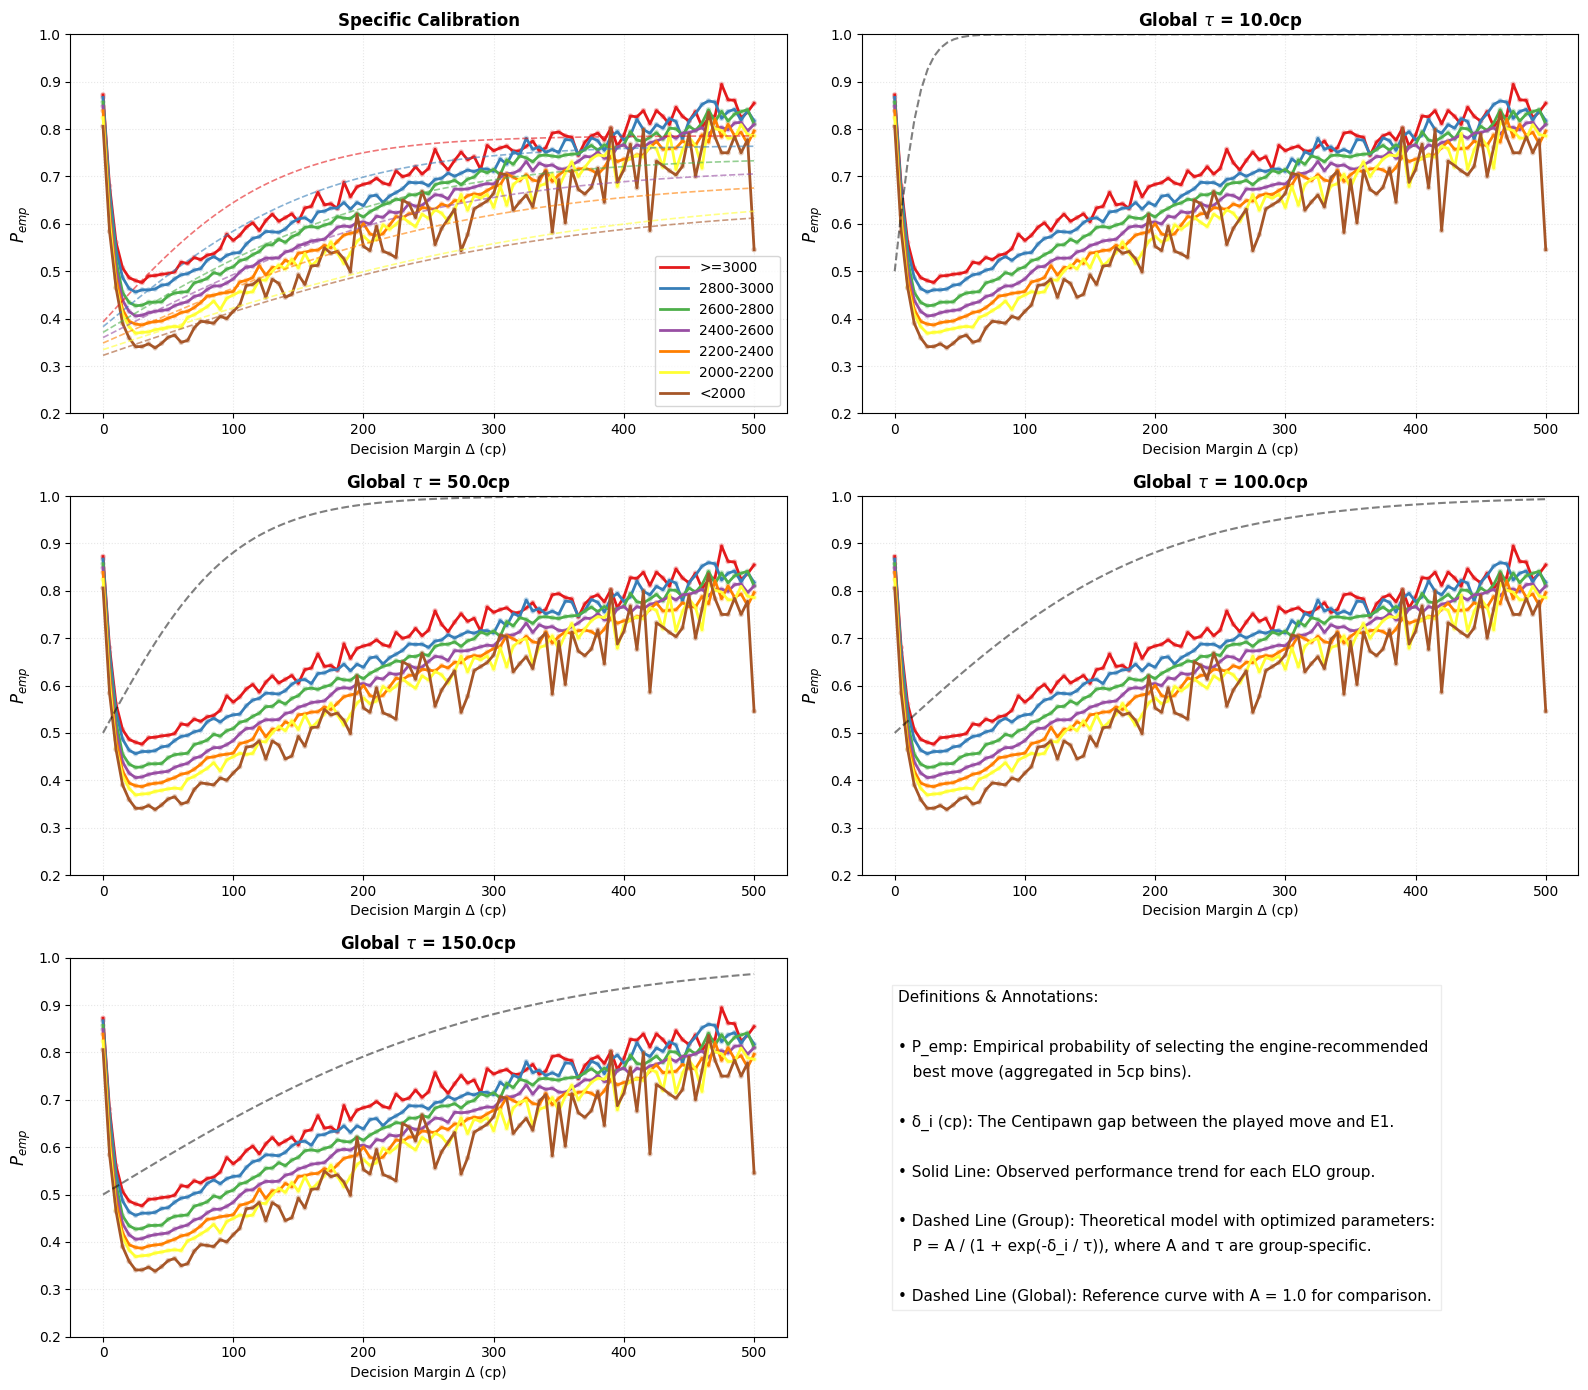

In [ ]:
elo_order=['>=3000', '2800-3000', '2600-2800', '2400-2600', '2200-2400', '2000-2200', '<2000'] # 确保图例和曲线颜色从高到低一致
distinct_palette = sns.color_palette("Set1", len(elo_order))
# 基于较大数据集拟合结果
elo_params = {
    '>=3000':      {'A': 0.786, 'tau': 65.8},
    '2800-3000':   {'A': 0.766, 'tau': 85.4},
    '2600-2800':   {'A': 0.742, 'tau': 113.2},
    '2400-2600':   {'A': 0.720, 'tau': 129.0},
    '2200-2400':   {'A': 0.697, 'tau': 144.7},
    '2000-2200':   {'A': 0.669, 'tau': 185.6},
    '<2000':      {'A': 0.645, 'tau': 170.8}
}

def plot_delta_performance(data, delta_col, title, ax, tau_val=None, is_group_specific=False):
    """
    重构后的绘图函数：支持单条 Global 参考线或多条 Elo-specific 参考线
    """
    # 高速聚合逻辑保持不变
    plot_df = data[(data[delta_col] >= 0) & (data[delta_col] <= 500)].copy()
    plot_df['Delta_Bin'] = (plot_df[delta_col] // 5) * 5
    
    agg_data = (plot_df.groupby(['ELO_Group', 'Delta_Bin'])['Is_Optimal']
                .mean().reset_index()
                .rename(columns={'Is_Optimal': 'P_emp'}))

    # 1. 绘制实测数据 (散点与实线)
    for i, group in enumerate(elo_order):
        group_data = agg_data[agg_data['ELO_Group'] == group]
        color = distinct_palette[i]
        # 实测散点
        ax.scatter(group_data['Delta_Bin'], group_data['P_emp'], 
                   color=color, s=15, alpha=0.3, edgecolor='none')
        # 实测平滑趋势线
        sns.lineplot(data=group_data, x='Delta_Bin', y='P_emp', 
                     color=color, linewidth=2, ax=ax, 
                     label=group if is_group_specific else None)

    # 2. 绘制理论参考曲线 (Dashed Lines)
    x_ref = np.linspace(0, 500, 100)
    
    if is_group_specific:
        # 模式 A: 针对每个 Elo 组绘制对应的 A 和 tau 理论线
        for i, group in enumerate(elo_order):
            A = elo_params[group]['A']
            tau = elo_params[group]['tau']
            color = distinct_palette[i]
            # 理论计算: P = A / (1 + exp(-delta/tau))
            y_ref = A / (1 + np.exp(-x_ref / tau))
            ax.plot(x_ref, y_ref, color=color, linestyle='--', alpha=0.6, linewidth=1.2)
        ax.set_title(title, fontsize=12, fontweight='bold')
    else:
        # 模式 B: Global 探测模式，使用单一黑色参考线，分子 A = 1
        y_ref = 1 / (1 + np.exp(-x_ref / tau_val))
        ax.plot(x_ref, y_ref, 'k--', alpha=0.5, linewidth=1.5, 
                label=f'Global Model ($\hat{{P}}$ @ $\\tau$={tau_val})')
        ax.set_title(title, fontsize=12, fontweight='bold')

    # 样式设置
    ax.set_xlabel(r'Decision Margin Δ (cp)', fontsize=10)
    ax.set_ylabel(r'$P_{emp}$', fontsize=12)
    ax.set_ylim(0.2, 1.0)
    ax.grid(True, linestyle=':', alpha=0.3)

fig = plt.figure(figsize=(16, 14))
gs = fig.add_gridspec(3, 2)

# 第一个格子: Group-specific，展示 7 条拟合出的模型线
ax0 = fig.add_subplot(gs[0, 0])
plot_delta_performance(df_moves, 'Δ', 'Specific Calibration', ax0, is_group_specific=True)

# 随后的格子: Global 探测
for idx, tau in enumerate(GLOBAL_τ_List[:4]):
    row, col = (idx + 1) // 2, (idx + 1) % 2
    ax = fig.add_subplot(gs[row, col])
    plot_delta_performance(df_moves, 'Δ', f'Global $\\tau$ = {tau}cp', ax, tau_val=tau)

# 最后一个格子: 术语与公式说明
ax_legend = fig.add_subplot(gs[2, 1])
ax_legend.axis('off')
legend_text = (
    "Definitions & Annotations:\n\n"
    "• P_emp: Empirical probability of selecting the engine-recommended\n"
    "   best move (aggregated in 5cp bins).\n\n"
    "• δ_i (cp): The Centipawn gap between the played move and E1.\n\n"
    "• Solid Line: Observed performance trend for each ELO group.\n\n"
    "• Dashed Line (Group): Theoretical model with optimized parameters:\n"
    "   P_model = A / (1 + exp(-δ_i / τ)), where A and τ are group-specific.\n\n"
    "• Dashed Line (Global): Reference curve with A = 1.0 for comparison."
)
ax_legend.text(0.05, 0.5, legend_text, fontsize=11, transform=ax_legend.transAxes, 
               va='center', linespacing=1.8, bbox=dict(facecolor='none', edgecolor='gray', alpha=0.15))

plt.tight_layout()
plt.show()

实测数据在 Δ 接近 0 时准确率极高，随后迅速下降，这在国际象棋中被称为**“简单局面悖论”**：
 
高准确率起点 ( Δ 接近 0 )：当 Δ 非常小时，意味着局面处于“非关键期”。此时最好的两步棋评分几乎一样，根据你的定义（容差 $10cp$），玩家只要不走错得离谱，几乎随便走一步都是“最优”的 。此外，这也包含了大量的开局库（Book moves）和强制招法（Forced moves），这些棋步几乎不需要思考就能走对 。     

触底下降区：随着 Δ 略微增大，局面进入“关键期（Critical positions）”。此时正确的路径只有一条，而替代方案虽然只差一点点，但已经足以致命。人类在面对这种“微妙但重要”的差异时最容易犯错，因此准确率降至最低 。     

逐步回升区：当 Δ 变得很大（如 $200cp$ 以上）时，最优解变得非常“直观”（例如白捡一个子），此时准确率才开始遵循你的理论模型，随难度的降低而回升 。

原始不分箱子的，可能会有很多毛刺。    
换大数据集的时候同样记得改delta_col的范围为1000-1500cp

<>:44: SyntaxWarning: invalid escape sequence '\h'
<>:44: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_21148\2057747849.py:44: SyntaxWarning: invalid escape sequence '\h'
  label=f'Global Model ($\hat{{P}}$ @ $\\tau$={tau_val})')


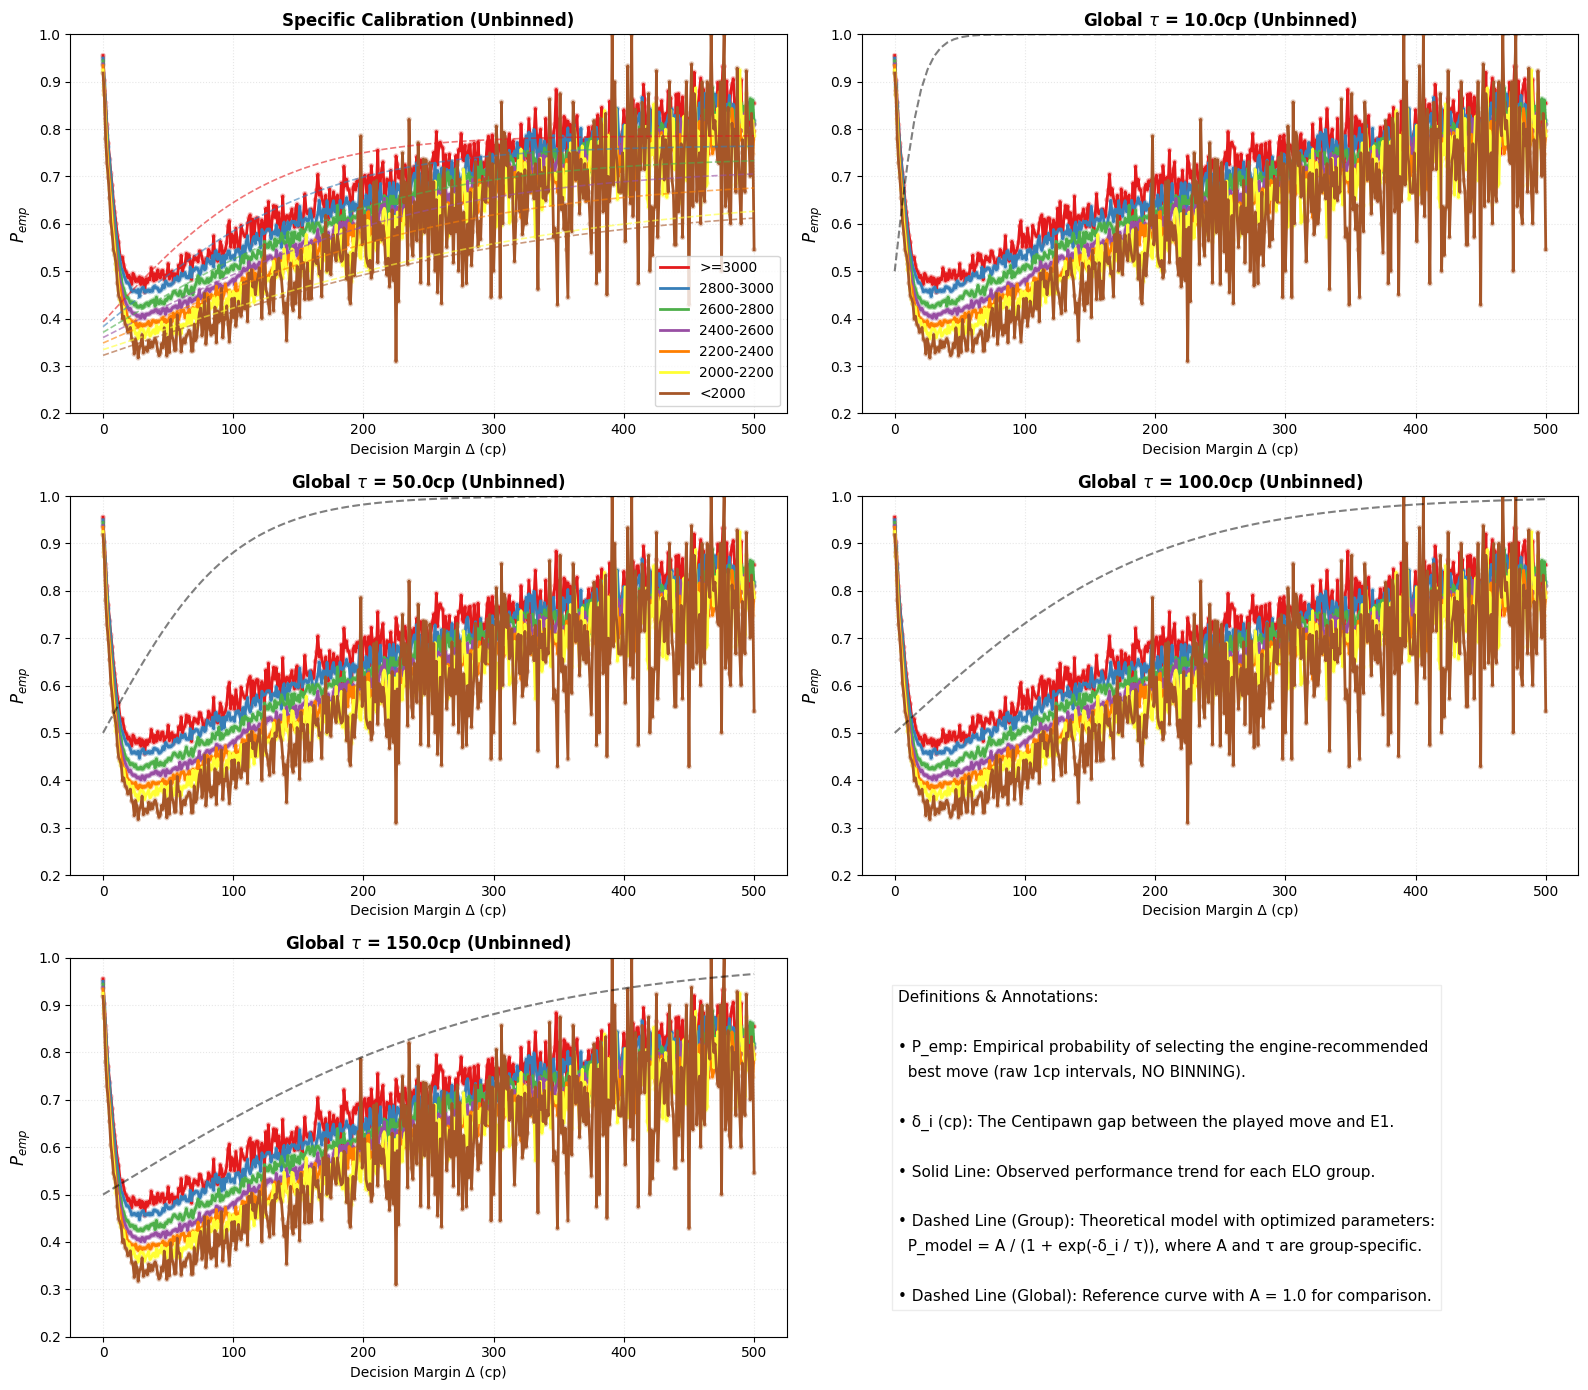

In [18]:
def plot_delta_performance_unbinned(data, delta_col, title, ax, tau_val=None, is_group_specific=False):
    """
    不分箱版本的绘图函数：支持单条 Global 参考线或多条 Elo-specific 参考线
    """
    # 过滤数据范围
    plot_df = data[(data[delta_col] >= 0) & (data[delta_col] <= 500)].copy()
    
    # 【修改点 1】：删除了 Delta_Bin 分箱，直接按照原始 delta_col 分组计算均值
    agg_data = (plot_df.groupby(['ELO_Group', delta_col])['Is_Optimal']
                .mean().reset_index()
                .rename(columns={'Is_Optimal': 'P_emp'}))

    # 1. 绘制实测数据 (散点与实线)
    for i, group in enumerate(elo_order):
        group_data = agg_data[agg_data['ELO_Group'] == group]
        color = distinct_palette[i]
        
        # 【修改点 2】：x 轴改为原始 delta_col
        # 实测散点
        ax.scatter(group_data[delta_col], group_data['P_emp'], 
                   color=color, s=15, alpha=0.3, edgecolor='none')
        # 实测平滑趋势线
        sns.lineplot(data=group_data, x=delta_col, y='P_emp', 
                     color=color, linewidth=2, ax=ax, 
                     label=group if is_group_specific else None)

    # 2. 绘制理论参考曲线 (Dashed Lines) - 【完全保持原样】
    x_ref = np.linspace(0, 500, 100)
    
    if is_group_specific:
        # 模式 A: 针对每个 Elo 组绘制对应的 A 和 tau 理论线
        for i, group in enumerate(elo_order):
            A = elo_params[group]['A']
            tau = elo_params[group]['tau']
            color = distinct_palette[i]
            # 理论计算: P = A / (1 + exp(-delta/tau))
            y_ref = A / (1 + np.exp(-x_ref / tau))
            ax.plot(x_ref, y_ref, color=color, linestyle='--', alpha=0.6, linewidth=1.2)
        ax.set_title(title, fontsize=12, fontweight='bold')
    else:
        # 模式 B: Global 探测模式，使用单一黑色参考线，分子 A = 1
        y_ref = 1 / (1 + np.exp(-x_ref / tau_val))
        ax.plot(x_ref, y_ref, 'k--', alpha=0.5, linewidth=1.5, 
                label=f'Global Model ($\hat{{P}}$ @ $\\tau$={tau_val})')
        ax.set_title(title, fontsize=12, fontweight='bold')

    # 样式设置 - 【完全保持原样】
    ax.set_xlabel(r'Decision Margin Δ (cp)', fontsize=10)
    ax.set_ylabel(r'$P_{emp}$', fontsize=12)
    ax.set_ylim(0.2, 1.0)
    ax.grid(True, linestyle=':', alpha=0.3)

fig = plt.figure(figsize=(16, 14))
gs = fig.add_gridspec(3, 2)

# 第一个格子: Group-specific，展示 7 条拟合出的模型线
ax0 = fig.add_subplot(gs[0, 0])
plot_delta_performance_unbinned(df_moves, 'Δ', 'Specific Calibration (Unbinned)', ax0, is_group_specific=True)

# 随后的格子: Global 探测
for idx, tau in enumerate(GLOBAL_τ_List[:4]):
    row, col = (idx + 1) // 2, (idx + 1) % 2
    ax = fig.add_subplot(gs[row, col])
    plot_delta_performance_unbinned(df_moves, 'Δ', f'Global $\\tau$ = {tau}cp (Unbinned)', ax, tau_val=tau)

# 最后一个格子: 术语与公式说明
ax_legend = fig.add_subplot(gs[2, 1])
ax_legend.axis('off')
legend_text = (
    "Definitions & Annotations:\n\n"
    "• P_emp: Empirical probability of selecting the engine-recommended\n"
    "  best move (raw 1cp intervals, NO BINNING).\n\n"
    "• δ_i (cp): The Centipawn gap between the played move and E1.\n\n"
    "• Solid Line: Observed performance trend for each ELO group.\n\n"
    "• Dashed Line (Group): Theoretical model with optimized parameters:\n"
    "  P_model = A / (1 + exp(-δ_i / τ)), where A and τ are group-specific.\n\n"
    "• Dashed Line (Global): Reference curve with A = 1.0 for comparison."
)
ax_legend.text(0.05, 0.5, legend_text, fontsize=11, transform=ax_legend.transAxes, 
               va='center', linespacing=1.8, bbox=dict(facecolor='none', edgecolor='gray', alpha=0.15))

plt.tight_layout()
plt.show()


认知速度的具体画图与分析    
### distribution: very long tail

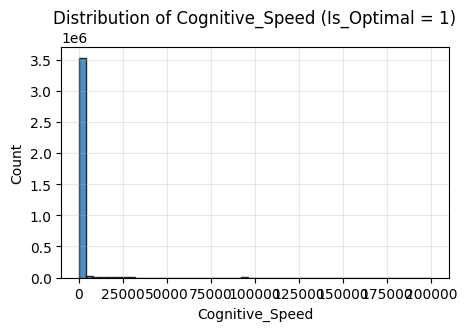

Bin: 0.00  -  3999.20  Counts: 3530959
Bin: 3999.20  -  7998.40  Counts: 24983
Bin: 7998.40  -  11997.60  Counts: 9156
Bin: 11997.60  -  15996.80  Counts: 4477
Bin: 15996.80  -  19996.00  Counts: 2678
Bin: 19996.00  -  23995.20  Counts: 1969
Bin: 23995.20  -  27994.40  Counts: 1786
Bin: 27994.40  -  31993.60  Counts: 2419
Bin: 31993.60  -  35992.80  Counts: 998
Bin: 35992.80  -  39992.00  Counts: 113
Bin: 39992.00  -  43991.20  Counts: 452
Bin: 43991.20  -  47990.40  Counts: 1295
Bin: 47990.40  -  51989.60  Counts: 812
Bin: 51989.60  -  55988.80  Counts: 1007
Bin: 55988.80  -  59988.00  Counts: 1029
Bin: 59988.00  -  63987.20  Counts: 358
Bin: 63987.20  -  67986.40  Counts: 84
Bin: 67986.40  -  71985.60  Counts: 16
Bin: 71985.60  -  75984.80  Counts: 4
Bin: 75984.80  -  79984.00  Counts: 4
Bin: 79984.00  -  83983.20  Counts: 4
Bin: 83983.20  -  87982.40  Counts: 14
Bin: 87982.40  -  91981.60  Counts: 507
Bin: 91981.60  -  95980.80  Counts: 2208
Bin: 95980.80  -  99980.00  Counts: 1241


In [33]:
speed_df = time_complex['Cognitive_Speed']
plt.figure(figsize=(5,3))
plt.hist(speed_df, bins=50, edgecolor='black', alpha=0.8)

plt.xlabel('Cognitive_Speed')
plt.ylabel('Count')
plt.title('Distribution of Cognitive_Speed (Is_Optimal = 1)')

plt.grid(alpha=0.3)
plt.show()

counts, edges = np.histogram(speed_df, bins = 50)
for i in range(len(counts)):
    print(f"Bin: {edges[i]:.2f}  -  {edges[i+1]:.2f}  Counts: {counts[i]}")

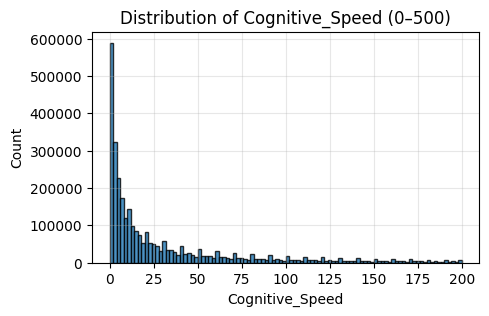

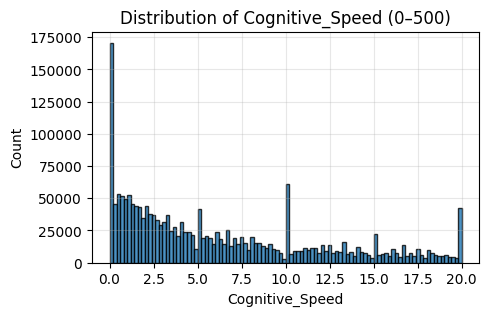

In [ ]:
speed_focus0 = speed_df[speed_df <= 200]
speed_focus1 = speed_df[speed_df <= 20]
# 0-200有85%的数据
plt.figure(figsize=(5,3))
plt.hist(speed_focus0, bins=100, edgecolor='black', alpha=0.8)
plt.xlabel('Cognitive_Speed')
plt.ylabel('Count')
plt.title('Distribution of Cognitive_Speed (0–500)')
plt.grid(alpha=0.3)
plt.show()
# 0-20有50%的数据
plt.figure(figsize=(5,3))
plt.hist(speed_focus1, bins=100, edgecolor='black', alpha=0.8)
plt.xlabel('Cognitive_Speed')
plt.ylabel('Count')
plt.title('Distribution of Cognitive_Speed (0–500)')
plt.grid(alpha=0.3)
plt.show()

In [25]:
print(speed_df.describe())

count    3.589298e+06
mean     4.782977e+02
std      4.324215e+03
min      0.000000e+00
25%      3.846154e+00
50%      1.679487e+01
75%      7.777778e+01
max      1.999600e+05
Name: Cognitive_Speed, dtype: float64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_21148\3608538584.py:51: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


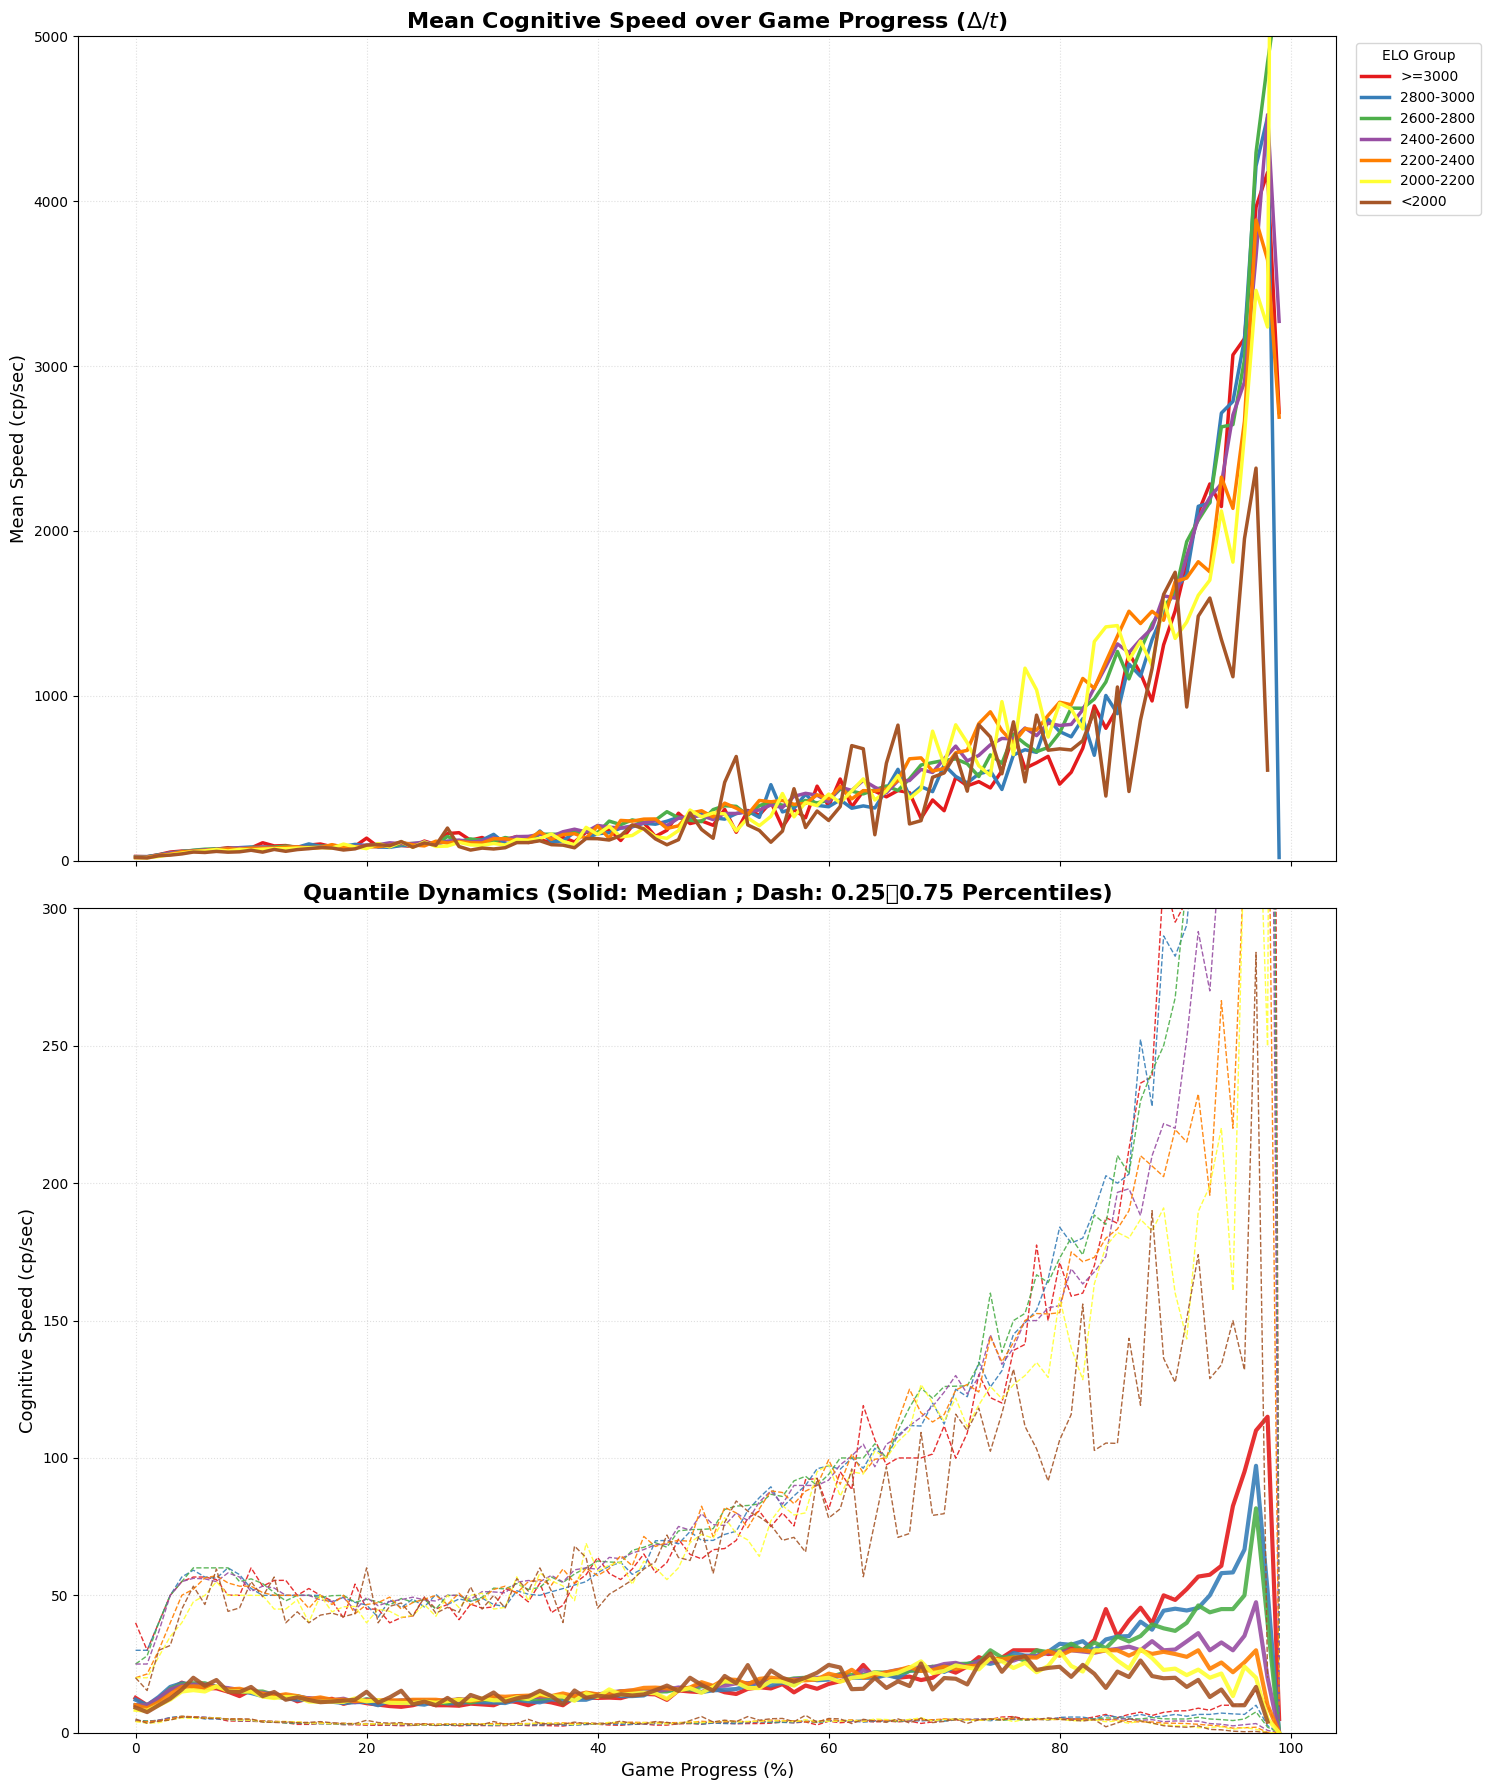

In [62]:
elo_order = ['>=3000', '2800-3000', '2600-2800', '2400-2600', '2200-2400', '2000-2200', '<2000']
distinct_palette = sns.color_palette("Set1", len(elo_order))
color_map = dict(zip(elo_order, distinct_palette))

# 分箱聚合 (100个 Progress 点)
time_complex['Progress_Bin'] = (time_complex['Progress'] * 100).astype(int)

# 聚合统计：0.25 0.5 0.75三个核心分位数
agg_metrics = time_complex.groupby(['ELO_Group', 'Progress_Bin'])['Cognitive_Speed'].agg(
    mean='mean',
    q25=lambda x: x.quantile(0.25),
    q50='median',
    q75=lambda x: x.quantile(0.75)
).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 18), sharex=True)

# 均值对比图
for group in elo_order:
    g_data = agg_metrics[agg_metrics['ELO_Group'] == group]
    ax1.plot(g_data['Progress_Bin'], g_data['mean'], 
             color=color_map[group], linewidth=2.5, label=group)

ax1.set_title(r'Mean Cognitive Speed over Game Progress ($\Delta/t$)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Mean Speed (cp/sec)', fontsize=13)
ax1.set_ylim(0, 5000)  # 均值天花板设为 5000
ax1.grid(True, linestyle=':', alpha=0.4)
ax1.legend(title='ELO Group', bbox_to_anchor=(1.01, 1), loc='upper left')

# 分位数分布图
for group in elo_order:
    g_data = agg_metrics[agg_metrics['ELO_Group'] == group]
    color = color_map[group]
    
    # q50 实线
    ax2.plot(g_data['Progress_Bin'], g_data['q50'], color=color, 
             linestyle='-', linewidth=3, alpha=0.9)
    
    # q25 & q75 虚线
    ax2.plot(g_data['Progress_Bin'], g_data['q25'], color=color, 
             linestyle='--', linewidth=1.0, alpha=0.9)
    ax2.plot(g_data['Progress_Bin'], g_data['q75'], color=color, 
             linestyle='--', linewidth=1.0, alpha=0.9)

ax2.set_title(r'Quantile Dynamics (Solid: Median ; Dash: 0.25，0.75 Percentiles)', fontsize=16, fontweight='bold')
ax2.set_ylabel('Cognitive Speed (cp/sec)', fontsize=13)
ax2.set_xlabel('Game Progress (%)', fontsize=13)
ax2.set_ylim(0, 300)  # 分位数天花板设为 1200，观察中位区间的细微差别
ax2.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

棋局复杂度与棋手失误类型的关系

# Complexity 高低 → Blunder / Mistake 发生概率

In [63]:
pd.set_option('display.max_columns', None)
complex_drop_force.head()

,Unnamed: 0,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time,Game_Length,Progress,Relative_Stage(temp),τ_Group,P_model,S,P_model(Global=10.0cp),S(Global=10.0cp),P_model(Global=50.0cp),S(Global=50.0cp),P_model(Global=100.0cp),S(Global=100.0cp),P_model(Global=150.0cp),S(Global=150.0cp)
0,0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170),1.3,63,0.015873,Opening (0-33%),85.4,0.520480,0.942084,0.668188,0.581675,0.534943,0.902543,0.517493,0.950389,0.511665,0.966730
1,3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170),0.4,63,0.063492,Opening (0-33%),129.0,0.575011,0.798339,0.980160,0.028911,0.685680,0.544392,0.596283,0.745932,0.564636,0.824606
2,4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170),0.1,63,0.079365,Opening (0-33%),85.4,0.546702,0.871174,0.832018,0.265313,0.579324,0.787557,0.539915,0.889196,0.526641,0.925107
3,5,34,6,Petar Ratkovic,Black,39,32,37,67,71,72,-,0,0,7.0,24.0,2463,2400-2600,0,1,178.3,Rich (>170),0.0,63,0.095238,Opening (0-33%),129.0,0.546378,0.872029,0.916827,0.125278,0.617748,0.694910,0.559714,0.837239,0.539915,0.889196
4,8,34,9,Dennis Wagner,White,32,39,23,17,12,11,-,0,0,7.0,21.0,2802,2800-3000,0,1,179.6,Rich (>170),0.2,63,0.142857,Opening (0-33%),85.4,0.561167,0.833497,0.890903,0.166659,0.603483,0.728614,0.552308,0.856455,0.534943,0.902543


In [64]:
df_moves.columns

Index(['Unnamed: 0', 'uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2',
       'E3', 'E4', 'E5', 'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ',
       'ELO', 'ELO_Group', 'Is_Forced', 'Is_Optimal', 'Remain_Time',
       'Time_Group', 'Move_Time', 'Game_Length', 'Progress',
       'Relative_Stage(temp)', 'τ_Group', 'P_model', 'S',
       'P_model(Global=10.0cp)', 'S(Global=10.0cp)', 'P_model(Global=50.0cp)',
       'S(Global=50.0cp)', 'P_model(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_model(Global=150.0cp)', 'S(Global=150.0cp)'],
      dtype='object')

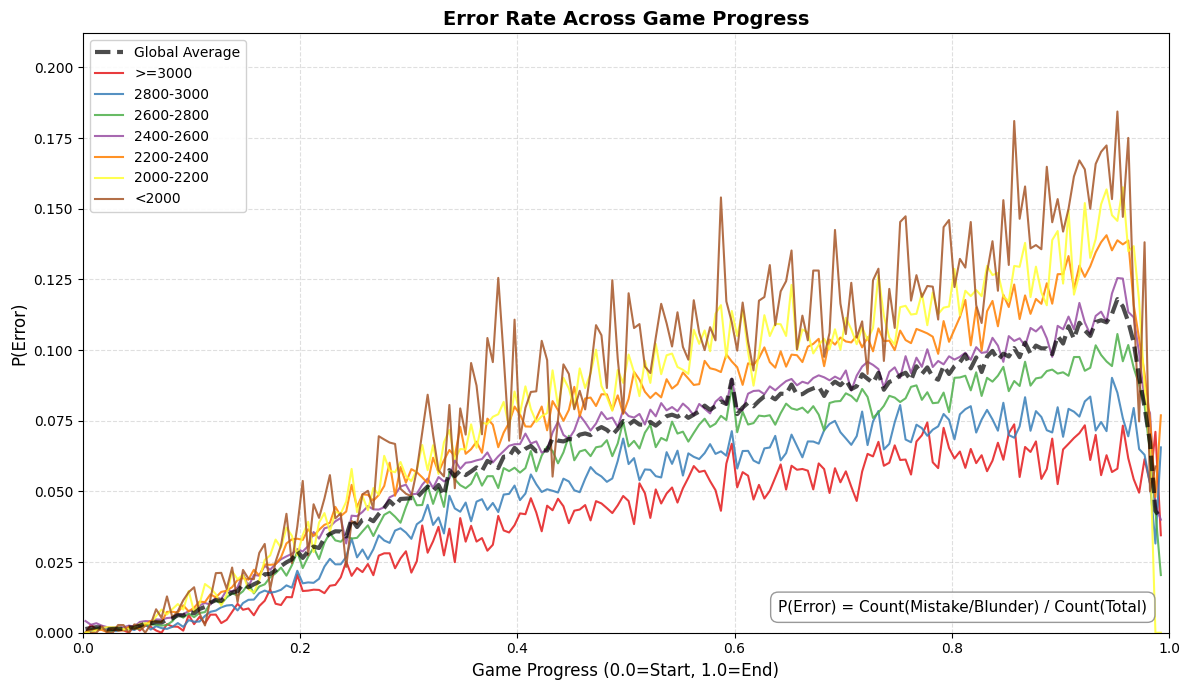

In [69]:
def plot_error_rate_by_progress_fast(df, bins=100):    
    # 分箱计算
    bin_indices = np.clip((df['Progress'].values * bins).astype(int), 0, bins - 1)
    
    # 避免超出内存，仅提取要用的数据
    temp_df = pd.DataFrame({'ELO_Group': df['ELO_Group'].values, 'Bin_Idx': bin_indices, 'Is_Error': df['Is_Error'].values})
    
    # 各个 ELO 组的统计量
    group_stats = temp_df.groupby(['ELO_Group', 'Bin_Idx'], observed=False)['Is_Error'].agg(['sum', 'count']).reset_index()
    group_stats['Error_Rate'] = group_stats['sum'] / group_stats['count']
    group_stats['Progress_Mid'] = (group_stats['Bin_Idx'] + 0.5) / bins

    # 全局 (Global) 的统计量， 用已聚合的 group_stats 二次聚合
    global_stats = group_stats.groupby('Bin_Idx')[['sum', 'count']].sum().reset_index()
    global_stats['Error_Rate'] = global_stats['sum'] / global_stats['count']
    global_stats['Progress_Mid'] = (global_stats['Bin_Idx'] + 0.5) / bins

    plt.figure(figsize=(12, 7))
    ax = plt.gca()
    
    # 画全局均线 (加粗、黑色、虚线，放在底层或顶层都可以，这里设为较高的 zorder 让它明显一点)
    ax.plot(global_stats['Progress_Mid'], global_stats['Error_Rate'], 
        color='black', linestyle='--', linewidth=3, alpha=0.7, label='Global Average',zorder=3)
    # ELO 分组线
    for i, group in enumerate(elo_order):
        group_data = group_stats[group_stats['ELO_Group'] == group]
        group_data = group_data.sort_values('Progress_Mid')
        
        ax.plot(group_data['Progress_Mid'],group_data['Error_Rate'], 
            color=distinct_palette[i], linewidth=1.5, alpha=0.85, label=group,zorder=2)
    
    plt.title("Error Rate Across Game Progress", fontsize=14, fontweight='bold')
    plt.xlabel("Game Progress (0.0=Start, 1.0=End)", fontsize=12)
    plt.ylabel("P(Error)", fontsize=12)
    plt.xlim(0, 1)
    max_y = max(group_stats['Error_Rate'].max(), global_stats['Error_Rate'].max())
    plt.ylim(0, max_y * 1.15) 
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend(loc='upper left', framealpha=0.9)
    text_str = "P(Error) = Count(Mistake/Blunder) / Count(Total)"
    props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8)
    ax.text(0.98, 0.03, text_str, transform=ax.transAxes, fontsize=11,verticalalignment='bottom', horizontalalignment='right', bbox=props, zorder=4)

    plt.tight_layout()
    plt.show()

plot_error_rate_by_progress_fast(complex_drop_force, bins=200)

In [70]:
total_moves = len(complex_drop_force)
total_errors = complex_drop_force['Is_Error'].sum()
overall_error_rate = total_errors / total_moves

print(f"总步数: {total_moves}")
print(f"总错误步数: {total_errors}")
print(f"整体错误率: {overall_error_rate:.2%}")

总步数: 6653089
总错误步数: 415544
整体错误率: 6.25%


=== Mistake / Blunder 's Game-Progress distribution 每个区间步数 ===
0.004-0.024: 199               | 0.024-0.043: 156
0.043-0.063: 273               | 0.063-0.083: 470
0.083-0.103: 767               | 0.103-0.123: 1198
0.123-0.142: 1733              | 0.142-0.162: 2278
0.162-0.182: 3111              | 0.182-0.202: 3662
0.202-0.221: 4503              | 0.221-0.241: 5311
0.241-0.261: 5888              | 0.261-0.281: 6424
0.281-0.301: 7188              | 0.301-0.320: 7676
0.320-0.340: 8165              | 0.340-0.360: 8694
0.360-0.380: 9147              | 0.380-0.399: 9315
0.399-0.419: 10192             | 0.419-0.439: 10043
0.439-0.459: 10405             | 0.459-0.478: 10727
0.478-0.498: 10178             | 0.498-0.518: 11426
0.518-0.538: 11043             | 0.538-0.558: 11056
0.558-0.577: 11216             | 0.577-0.597: 11718
0.597-0.617: 11186             | 0.617-0.637: 11574
0.637-0.656: 11592             | 0.656-0.676: 11535
0.676-0.696: 11545             | 0.696-0.716: 11440
0.716-0.735: 

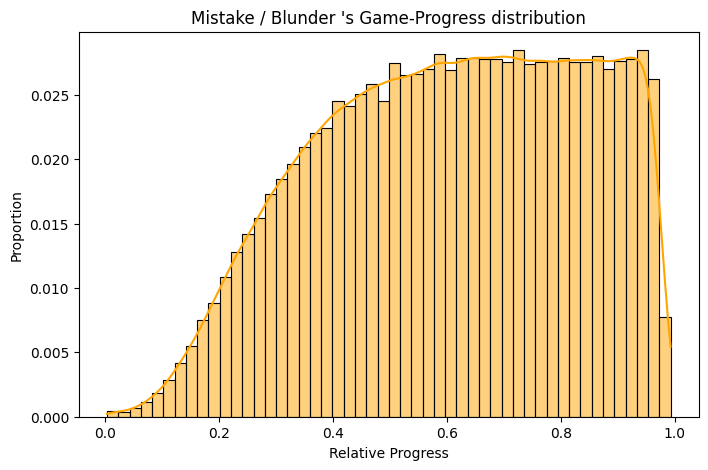

In [ ]:
# 这张图是为了看mistake blunder主要分布在游戏的哪个阶段比较多，纵坐标的百分比占比
# 可以看出开局阶段很少有失误， 但是中后局选手出错概率增加很多
def plot_hist_with_values(df, col, bins=50, kde=False, title=None, xlabel=None, ylabel='Relative Frequency (Probability)', color='blue'):
    """绘制直方图/柱状图并打印每个区间的具体步数。"""
    values = df[col].dropna()
    
    counts, bin_edges = np.histogram(values, bins=bins)
    
    print(f"=== {title if title else col} 每个区间步数 ===")
    for i in range(0, len(counts), 2):
        left = f"{bin_edges[i]:.3f}-{bin_edges[i+1]:.3f}: {counts[i]}"
        if i + 1 < len(counts):
            right = f"{bin_edges[i+1]:.3f}-{bin_edges[i+2]:.3f}: {counts[i+1]}"
            print(f"{left:<30} | {right}")
        else:
            print(left)

    plt.figure(figsize=(8,5))
    sns.histplot(values, bins=bins, kde=kde, color=color, stat='probability')
    plt.title(title if title else col)
    plt.xlabel(xlabel if xlabel else col)
    plt.ylabel(ylabel)
    plt.show() 
# mistake blunder distribution
# 只保留错误步
errors_df = complex_drop_force[complex_drop_force['Is_Error']==1]

plot_hist_with_values(df=errors_df, col='Progress', bins=50, kde=True, title="Mistake / Blunder 's Game-Progress distribution", xlabel='Relative Progress', ylabel='Proportion',color='orange')

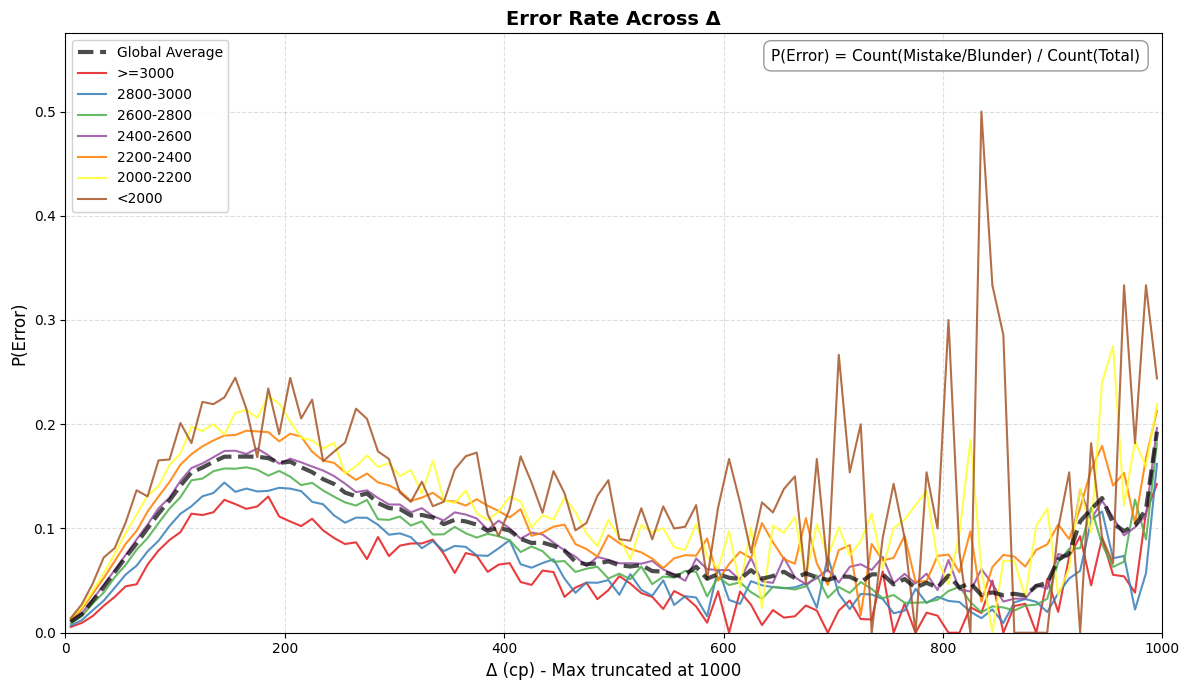

In [80]:
def plot_error_rate_by_delta_fast(df, delta_col='Δ', max_delta=500, bins=100): 
    """
    横轴为 Δ，纵轴为 P(Error) 的极速版折线图
    """
    # 1. 极速分箱计算：把 0 ~ max_delta 的连续值映射为 0 ~ bins-1 的整数索引
    vals = np.clip(df[delta_col].values, 0, max_delta)
    # 乘以 bins 并取整，确保最大值不会越界
    bin_indices = np.clip((vals / max_delta * bins).astype(int), 0, bins - 1)
    
    # 2. 避免超出内存，仅提取要用的数据
    temp_df = pd.DataFrame({
        'ELO_Group': df['ELO_Group'].values, 
        'Bin_Idx': bin_indices, 
        'Is_Error': df['Is_Error'].values
    })
    
    # 3. 各个 ELO 组的统计量
    group_stats = temp_df.groupby(['ELO_Group', 'Bin_Idx'], observed=False)['Is_Error'].agg(['sum', 'count']).reset_index()
    group_stats['Error_Rate'] = group_stats['sum'] / group_stats['count']
    # 将 Bin_Idx 转换回实际的 Δ 中心值作为 X 轴
    bin_width = max_delta / bins
    group_stats['Delta_Mid'] = (group_stats['Bin_Idx'] + 0.5) * bin_width

    # 4. 全局 (Global) 的统计量， 用已聚合的 group_stats 二次聚合
    global_stats = group_stats.groupby('Bin_Idx')[['sum', 'count']].sum().reset_index()
    global_stats['Error_Rate'] = global_stats['sum'] / global_stats['count']
    global_stats['Delta_Mid'] = (global_stats['Bin_Idx'] + 0.5) * bin_width

    # 5. 开始绘图
    plt.figure(figsize=(12, 7))
    ax = plt.gca()
    
    # 画全局均线 (加粗、黑色、虚线)
    ax.plot(global_stats['Delta_Mid'], global_stats['Error_Rate'], 
            color='black', linestyle='--', linewidth=3, alpha=0.7, label='Global Average', zorder=3)
    
    # ELO 分组线
    for i, group in enumerate(elo_order):
        group_data = group_stats[group_stats['ELO_Group'] == group]
        group_data = group_data.sort_values('Delta_Mid')
        
        ax.plot(group_data['Delta_Mid'], group_data['Error_Rate'], 
                color=distinct_palette[i], linewidth=1.5, alpha=0.85, label=group, zorder=2)
    
    # 6. 设置图表轴与标签
    plt.title(f"Error Rate Across {delta_col}", fontsize=14, fontweight='bold')
    plt.xlabel(f"{delta_col} (cp) - Max truncated at {max_delta}", fontsize=12)
    plt.ylabel("P(Error)", fontsize=12)
    
    plt.xlim(0, max_delta)
    # 过滤掉 NaN 来计算最高点，防止空箱子导致绘图报错
    max_y = max(group_stats['Error_Rate'].max(), global_stats['Error_Rate'].max())
    plt.ylim(0, max_y * 1.15) 
    
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend(loc='upper left', framealpha=0.9)
    
    text_str = "P(Error) = Count(Mistake/Blunder) / Count(Total)"
    props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8)
    ax.text(0.98, 0.95, text_str, transform=ax.transAxes, fontsize=11,
            verticalalignment='bottom', horizontalalignment='right', bbox=props, zorder=4)

    plt.tight_layout()
    plt.show()

# 调用测试：你可以把 delta_col 换成你实际的列名，比如 'Δ0' 或者 'Δ'
plot_error_rate_by_delta_fast(complex_drop_force, delta_col='Δ', max_delta=1000, bins=100)

In [81]:
df_moves.head()

,Unnamed: 0,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time,Game_Length,Progress,Relative_Stage(temp),τ_Group,P_model,S,P_model(Global=10.0cp),S(Global=10.0cp),P_model(Global=50.0cp),S(Global=50.0cp),P_model(Global=100.0cp),S(Global=100.0cp),P_model(Global=150.0cp),S(Global=150.0cp)
0,0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170),1.3,63,0.015873,Opening (0-33%),85.4,0.520480,0.942084,0.668188,0.581675,0.534943,0.902543,0.517493,0.950389,0.511665,0.966730
1,1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,3.0,4.0,2463,2400-2600,0,1,177.8,Rich (>170),-0.9,63,0.031746,Opening (0-33%),129.0,0.507751,0.977806,0.598688,0.740125,0.519989,0.943446,0.509999,0.971435,0.506666,0.980892
2,2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,6.0,8.0,2802,2800-3000,0,1,178.5,Rich (>170),-0.7,63,0.047619,Opening (0-33%),85.4,0.523402,0.934008,0.689974,0.535385,0.539915,0.889196,0.519989,0.943446,0.513330,0.962041
3,3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170),0.4,63,0.063492,Opening (0-33%),129.0,0.575011,0.798339,0.980160,0.028911,0.685680,0.544392,0.596283,0.745932,0.564636,0.824606
4,4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170),0.1,63,0.079365,Opening (0-33%),85.4,0.546702,0.871174,0.832018,0.265313,0.579324,0.787557,0.539915,0.889196,0.526641,0.925107


In [82]:
def get_relative_stage(progress):
    if progress <= 0.33:
        return 'Opening (0-33%)'
    elif progress <= 0.66:
        return 'Middlegame (33-66%)'
    else:
        return 'Endgame (66-100%)'
df_moves['Relative_Stage(temp)'] = df_moves['Progress'].apply(get_relative_stage)

In [ ]:
plt.figure(figsize=(10, 6))

# 画 Group-specific S
sns.lineplot(
    x=df_moves['Progress'].round(2),
    y=df_moves['S'],
    estimator='mean',
    errorbar=None,
    label='S (Group)'
)

# 自动找所有 Global S 列
global_s_cols = [col for col in df_moves.columns if col.startswith('S(Global=')]

# 画 Global S
for col in global_s_cols:
    sns.lineplot(
        x=df_moves['Progress'].round(2),
        y=df_moves[col],
        estimator='mean',
        errorbar=None,
        label=col.replace('S(', '').replace(')', '')
    )

plt.ylim(0, 1)
plt.title("Complexity (S) Trend over Game Progress")
plt.xlabel("Game Progress (0.0 = Start, 1.0 = Finish)")
plt.ylabel("Average Complexity (S)")
plt.axvline(0.33, color='r', linestyle='--', alpha=0.3, label='1/3 Split')
plt.axvline(0.66, color='r', linestyle='--', alpha=0.3)
plt.legend(fontsize=6)
plt.grid(True, alpha=0.3)
plt.show()


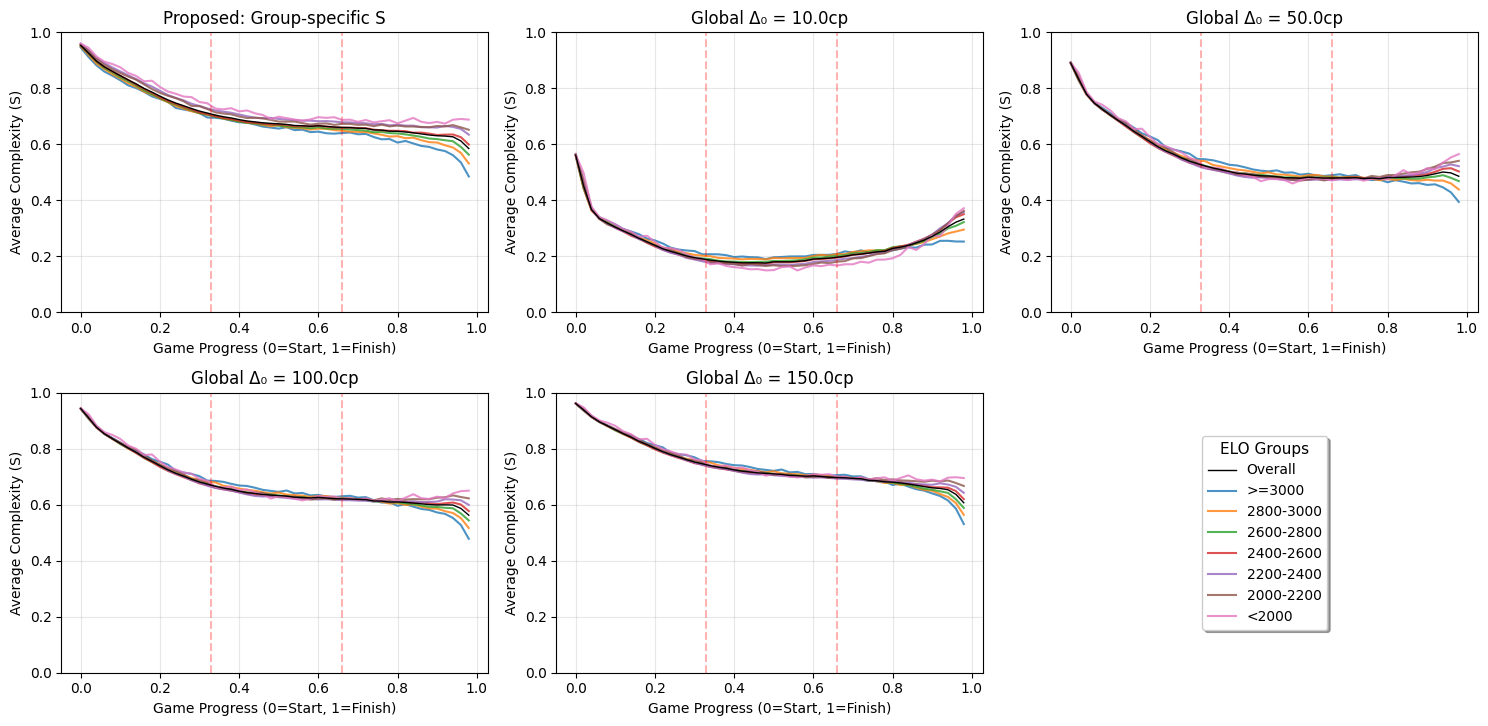

In [ ]:
n_bins = 50
df_moves['Progress_bin'] = pd.cut(df_moves['Progress'], bins=n_bins, labels=False)

# --- 绘图准备 ---
n_cols = 3
plot_cols = ['S'] + global_s_cols

n_plots = len(plot_cols)
n_rows = math.ceil((n_plots + 1) / n_cols) # 确保为图例留出位置

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()
palette = sns.color_palette("tab10", n_colors=len(elo_order))

for i, col in enumerate(plot_cols):
    ax = axes[i]
    
    # 整体平均线
    overall_avg = df_moves.groupby('Progress_bin')[col].mean()
    ax.plot(overall_avg.index / n_bins, overall_avg.values, color='black', linewidth=1, label='Overall', zorder=10)

    # 各 ELO 组曲线
    for j, elo in enumerate(elo_order):
        sub_df = df_moves[df_moves['ELO_Group'] == elo]
        group_avg = sub_df.groupby('Progress_bin')[col].mean()
        ax.plot(group_avg.index / n_bins, group_avg.values, color=palette[j], label=str(elo), alpha=0.8)

    # 样式美化
    ax.set_title("Proposed: Group-specific S" if col=='S' else f"Global Δ₀ = {col.split('=')[1].replace(')','')}", fontsize=12)
    ax.set_xlabel("Game Progress (0=Start, 1=Finish)")
    ax.set_ylabel("Average Complexity (S)")
    ax.set_ylim(0, 1)
    ax.axvline(0.33, color='r', linestyle='--', alpha=0.3)
    ax.axvline(0.66, color='r', linestyle='--', alpha=0.3)
    ax.grid(True, alpha=0.3)

# 图例
legend_ax = axes[n_plots] 
legend_ax.axis('off') 
handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(handles, labels, loc='center', title="ELO Groups", 
                  fontsize=10, title_fontsize=11, frameon=True, shadow=True)

# --- 清理多余的空白子图 ---
for j in range(n_plots + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

In [ ]:
df_moves.to_csv('peak.csv')